#  Curso: Monitoreo en producción (con Langfuse)

En la Clase 6 aprendiste a **ver una traza**. Hoy pasamos a la **vista de arriba**: vigilar
el sistema en *agregado* y enterarte cuando algo se degrada, sin revisar traza por traza.

Es la mitad *proactiva* de "producción" (la reactiva —debuggear una ejecución concreta— es
la Clase 8). La regla mental:

> **Monitoreo (hoy)** te dice *que* algo va mal y *dónde mirar*.
> **Debugging (Clase 8)** es entrar a esa ejecución y ver *por qué*.

### Objetivos
- ✅ Generar tráfico realista y observarlo en agregado
- ✅ Capturar **feedback de usuario** (👍/👎) con `create_score` sobre tus trazas
- ✅ Registrar una **señal de calidad automática** (confianza del retrieval) como score
- ✅ Leer dashboards de **latencia, costo y calidad** (en la UI y con un mini-dashboard local)
- ✅ Detectar **drift**: queries que se alejan de lo que tu RAG sabe responder
- ✅ Definir **alertas** por umbrales (costo, tasa de 👎, errores)

### Prerrequisito
Este notebook reusa tu setup de Langfuse de la Clase 6 (mismas claves). Corre las celdas 1–4
para reconstruir el sistema, y luego las PARTES 1–5.


## 1. Instalación

In [ ]:
!pip install transformers torch huggingface_hub pandas matplotlib rank_bm25 -q
!pip install langfuse -q

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

## 2. LLM y utilidades

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# (si no hiciste login de HuggingFace en esta sesion, descomenta:)
# from huggingface_hub import notebook_login; notebook_login()

print("🔄 Loading LLM...")
model_name = "google/gemma-3-1b-it"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
llm = pipeline("text-generation", model=model, tokenizer=tokenizer)

def ask_llm(prompt, max_new_tokens=60):
    out = llm([{"role": "user", "content": prompt}], max_new_tokens=max_new_tokens,
              do_sample=False, pad_token_id=tokenizer.eos_token_id, return_full_text=False)
    return out[0]["generated_text"].strip()

def count_tokens(text):
    return len(tokenizer.encode(text))

print("✅ LLM ready")

🔄 Loading LLM...


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.00GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

✅ LLM ready


## 3. Conectar con Langfuse (mismas claves de la Clase 6)

In [ ]:
import os
os.environ["LANGFUSE_HOST"]       = "https://us.cloud.langfuse.com"
os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-lf-8c53a053-7a99-4afe-9d78-ffc5ecc10432"
os.environ["LANGFUSE_SECRET_KEY"] = "sk-lf-ef93aaf8-901b-4c6b-83e2-ce51c55d9f1c"
# 🔒 Recuerda rotar la secret key cuando termines de probar (Settings -> API Keys)

from langfuse import get_client, propagate_attributes
langfuse = get_client()
print("✅ Conectado" if langfuse.auth_check() else "❌ auth_check fallo: revisa claves/host")

✅ Conectado


## 4. El sistema instrumentado

Dos cambios frente a la Clase 6, ambos para monitorear:
- `cloudbox_bot_traced` ahora **devuelve el `trace_id`** (lo necesitamos para adjuntar el
  feedback después) y la **confianza del retrieval** (score máximo de BM25 → señal de drift).
- Guardamos un `RUN_LOG` local en paralelo, para construir un mini-dashboard y *ver por dentro*
  lo que la plataforma calcula por ti.

In [ ]:
CORPUS = [
    {"id": "doc-01", "text": "CloudBox ofrece 15 GB de almacenamiento gratuito en el plan Free."},
    {"id": "doc-02", "text": "El plan Pro de CloudBox cuesta 9 dolares al mes e incluye 2 TB."},
    {"id": "doc-03", "text": "Para restaurar un archivo borrado, ve a la Papelera; se guardan 30 dias."},
    {"id": "doc-04", "text": "CloudBox cifra los archivos en reposo con AES-256 y en transito con TLS."},
    {"id": "doc-05", "text": "Puedes compartir una carpeta con un enlace de solo lectura o edicion."},
    {"id": "doc-06", "text": "El limite por archivo es 50 GB en Pro y 5 GB en Free."},
    {"id": "doc-07", "text": "CloudBox sincroniza en Windows, macOS, Android e iOS."},
    {"id": "doc-08", "text": "El soporte 24/7 por chat es solo para clientes del plan Pro."},
]
_bm25 = BM25Okapi([d["text"].lower().split() for d in CORPUS])

def retrieve_with_scores(query, k=3):
    scores = _bm25.get_scores(query.lower().split())
    idx = np.argsort(scores)[::-1][:k]
    docs = [CORPUS[i] for i in idx]
    confidence = float(scores[idx[0]]) if len(idx) else 0.0   # score BM25 del top-1
    return docs, confidence

def build_prompt(query, docs):
    contexto = "\n".join(f"- {d['text']}" for d in docs)
    return ("Responde usando SOLO el contexto. Si no esta, di que no lo sabes.\n\n"
            f"Contexto:\n{contexto}\n\nPregunta: {query}\nRespuesta:")

PRICE_IN, PRICE_OUT = 0.0005, 0.0015
RUN_LOG = []   # dashboard local en paralelo a Langfuse

def cloudbox_bot_traced(query, session_id="clase7-demo", user_id="user-0"):
    t0 = time.perf_counter()
    with langfuse.start_as_current_observation(as_type="span", name="cloudbox_bot") as root:
        trace_id = root.trace_id
        root.update(input={"query": query})
        with propagate_attributes(session_id=session_id, user_id=user_id,
                                  trace_name="cloudbox_bot"):
            with langfuse.start_as_current_observation(as_type="span", name="retrieve") as r:
                docs, confidence = retrieve_with_scores(query)
                r.update(output={"doc_ids": [d["id"] for d in docs]},
                         metadata={"retrieval_confidence": round(confidence, 3)})

            prompt = build_prompt(query, docs)
            with langfuse.start_as_current_observation(
                    as_type="generation", name="generate", model="gemma-3-1b-it") as gen:
                gen.update(input=prompt)
                answer = ask_llm(prompt)
                n_in, n_out = count_tokens(prompt), count_tokens(answer)
                cost = n_in/1000*PRICE_IN + n_out/1000*PRICE_OUT
                gen.update(output=answer,
                           usage_details={"input": n_in, "output": n_out, "total": n_in+n_out},
                           cost_details={"input": n_in/1000*PRICE_IN,
                                         "output": n_out/1000*PRICE_OUT, "total": cost})
        root.update(output={"answer": answer})

    latency_ms = (time.perf_counter() - t0) * 1000
    RUN_LOG.append({"query": query, "trace_id": trace_id, "user_id": user_id,
                    "latency_ms": round(latency_ms, 1), "tokens": n_in + n_out,
                    "cost": cost, "confidence": round(confidence, 3), "feedback": None})
    return answer, trace_id, confidence

print("✅ Sistema instrumentado (devuelve trace_id + confianza, y llena RUN_LOG)")

✅ Sistema instrumentado (devuelve trace_id + confianza, y llena RUN_LOG)


---
## PARTE 1 — Generar tráfico realista

Sin volumen no hay nada que monitorear. Lanzamos un lote de consultas: la mayoría **dentro**
del dominio de CloudBox, y unas cuantas **fuera** (capital de Francia, mundial, recetas) — que
son las que el monitoreo debe delatar.

In [ ]:
queries = [
    "¿Cuanto cuesta el plan Pro?",
    "¿Cuanto espacio da el plan Free?",
    "¿Como restauro un archivo borrado?",
    "¿CloudBox cifra mis archivos?",
    "¿Cual es el limite de tamano por archivo?",
    "¿En que plataformas sincroniza CloudBox?",
    "¿Como comparto una carpeta?",
    "¿El soporte es 24/7?",
    "¿Cual es la capital de Francia?",     # fuera de dominio
    "¿Quien gano el mundial 2022?",        # fuera de dominio
    "Dame una receta de tortilla",         # fuera de dominio
]

for i, q in enumerate(queries):
    cloudbox_bot_traced(q, session_id="clase7-demo", user_id=f"user-{i % 3}")

langfuse.flush()
print(f"✅ {len(queries)} trazas enviadas a Langfuse (y registradas en RUN_LOG)")

[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

✅ 11 trazas enviadas a Langfuse (y registradas en RUN_LOG)


---
## PARTE 2 — Feedback de usuario con `create_score`

El corazón de la clase. En producción, cuando un usuario pulsa 👍/👎, tu app llama a
`create_score` con el `trace_id` de esa respuesta. Aquí **simulamos** ese feedback: las
respuestas con baja confianza de retrieval reciben más 👎 (es lo que pasaría en la realidad).

Adjuntamos **dos** tipos de score, para que veas que un *score* no es solo humano:
- `user_feedback` (👍=1 / 👎=0) → señal **humana**
- `retrieval_confidence` → señal **automática** calculada por el sistema

In [ ]:
random.seed(42)

# umbral heuristico de confianza: la mitad de la mediana del lote (calibrable)
median_conf = np.median([r["confidence"] for r in RUN_LOG])
CONF_THRESHOLD = 0.5 * median_conf
print(f"Mediana de confianza del lote: {median_conf:.3f}  ->  umbral drift: {CONF_THRESHOLD:.3f}\n")

for rec in RUN_LOG:
    # --- score automatico: confianza del retrieval ---
    langfuse.create_score(name="retrieval_confidence", value=rec["confidence"],
                          trace_id=rec["trace_id"], data_type="NUMERIC")

    # --- score humano simulado: 👍/👎 ---
    p_up = 0.9 if rec["confidence"] >= CONF_THRESHOLD else 0.2
    fb = 1 if random.random() < p_up else 0
    rec["feedback"] = fb
    langfuse.create_score(name="user_feedback", value=fb, trace_id=rec["trace_id"],
                          data_type="NUMERIC", comment="👍" if fb else "👎")

    langfuse.create_score(name="test_score", value=random.random()+2, trace_id=rec["trace_id"],
                          data_type="NUMERIC", comment="testing scores")

langfuse.flush()
print("✅ Scores enviados. En la UI: abre una traza -> pestana Scores, o mira la tabla Scores.")

Mediana de confianza del lote: 1.851  ->  umbral drift: 0.925

✅ Scores enviados. En la UI: abre una traza -> pestana Scores, o mira la tabla Scores.


---
## PARTE 3 — Dashboards de latencia, costo y calidad

En Langfuse esto vive en **Dashboards** (y en los agregados de la tabla de trazas). Aquí lo
reconstruimos con pandas desde `RUN_LOG`, para entender *qué* calcula la plataforma: p50/p95
de latencia, costo total y por consulta, y la tasa de 👍.

===== DASHBOARD (local) =====
Consultas:            11
Latencia p50 / p95:   8653 / 14312 ms
Costo total:          $0.00066
Costo medio/consulta: $0.00006
Tasa de 👍:           82%
Confianza media:      1.711



,query,latency_ms,tokens,cost,confidence,feedback
0,¿Cuanto cuesta el plan Pro?,6693.7,102,0.000058,1.927,1
1,¿Cuanto espacio da el plan Free?,4404.7,100,0.000054,0.472,0
2,¿Como restauro un archivo borrado?,10282.2,116,0.000074,1.851,1
3,¿CloudBox cifra mis archivos?,4516.7,102,0.000054,1.559,1
4,¿Cual es el limite de tamano por archivo?,8653.3,111,0.000069,3.291,1
5,¿En que plataformas sincroniza CloudBox?,8352.2,107,0.000068,1.900,1
6,¿Como comparto una carpeta?,10151.1,102,0.000066,1.617,1
7,¿El soporte es 24/7?,4268.1,97,0.000052,2.577,1
8,¿Cual es la capital de Francia?,18341.4,108,0.000059,1.559,1
9,¿Quien gano el mundial 2022?,10060.4,102,0.000056,0.000,0


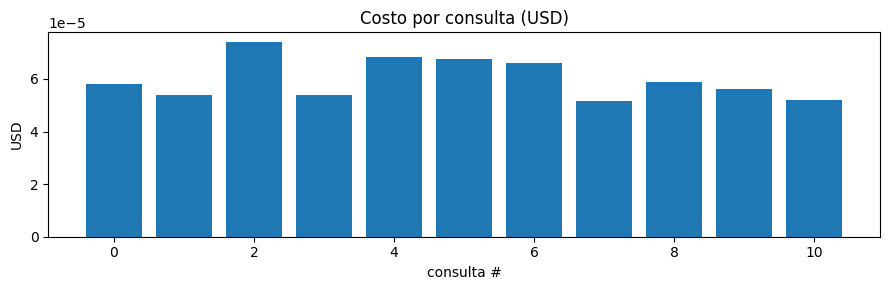


➡️  En Langfuse: Dashboards muestra estos mismos numeros en el tiempo, sin codigo.


In [ ]:
df = pd.DataFrame(RUN_LOG)

print("===== DASHBOARD (local) =====")
print(f"Consultas:            {len(df)}")
print(f"Latencia p50 / p95:   {df.latency_ms.quantile(.5):.0f} / {df.latency_ms.quantile(.95):.0f} ms")
print(f"Costo total:          ${df.cost.sum():.5f}")
print(f"Costo medio/consulta: ${df.cost.mean():.5f}")
print(f"Tasa de 👍:           {df.feedback.mean()*100:.0f}%")
print(f"Confianza media:      {df.confidence.mean():.3f}")
print()
display(df[["query", "latency_ms", "tokens", "cost", "confidence", "feedback"]])

# Un grafico simple: costo por consulta
plt.figure(figsize=(9, 3))
plt.bar(range(len(df)), df.cost)
plt.title("Costo por consulta (USD)"); plt.xlabel("consulta #"); plt.ylabel("USD")
plt.tight_layout(); plt.show()

print("\n➡️  En Langfuse: Dashboards muestra estos mismos numeros en el tiempo, sin codigo.")

---
## PARTE 4 — Detección de drift

**Drift** = las preguntas de los usuarios se alejan de lo que tu RAG sabe responder. Señal
barata y efectiva: la **confianza del retrieval**. Si el mejor documento recuperado apenas
matchea la query, probablemente estás fuera de dominio — y el LLM está a un paso de alucinar.

Marcamos como *posible drift* toda consulta por debajo del umbral. Fíjate en que las
fuera-de-dominio caen solas al fondo.

⚠️  2 de 11 consultas marcadas como posible drift (confianza < 0.925):

   [ 0.00]  ¿Quien gano el mundial 2022?
   [ 0.47]  ¿Cuanto espacio da el plan Free?


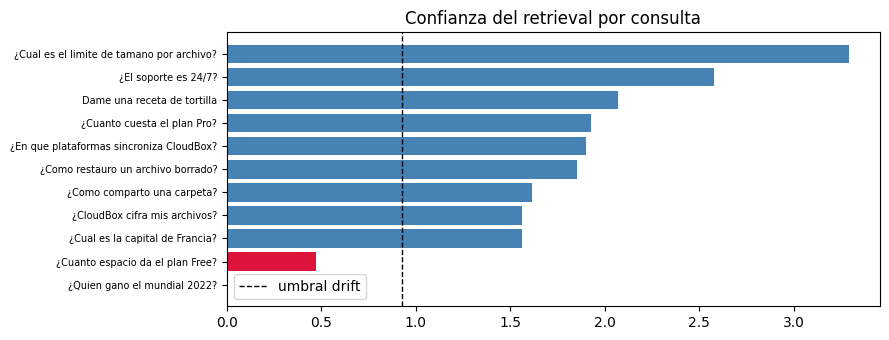


En producción: alerta si el % de consultas bajo umbral sube semana a semana.


In [ ]:
df["posible_drift"] = df["confidence"] < CONF_THRESHOLD

drift = df[df["posible_drift"]].sort_values("confidence")

print(
    f"⚠️  {len(drift)} de {len(df)} consultas marcadas como posible drift "
    f"(confianza < {CONF_THRESHOLD:.3f}):\n"
)

for _, r in drift.iterrows():
    print(f"   [{r['confidence']:5.2f}]  {r['query']}")


# Visual: confianza por consulta con la línea de umbral

order = df.sort_values("confidence")

plt.figure(figsize=(9, 3.5))

colors = [  "crimson" if c < CONF_THRESHOLD else "steelblue" for c in order["confidence"]]

plt.barh(range(len(order)), order["confidence"], color=colors)

plt.yticks(range(len(order)), order["query"], fontsize=7)

plt.axvline(CONF_THRESHOLD, color="black", ls="--", lw=1, label="umbral drift")

plt.title("Confianza del retrieval por consulta")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "\nEn producción: alerta si el % de consultas bajo umbral "
    "sube semana a semana."
)

---
## PARTE 5 — Alertas por umbrales

El objetivo del monitoreo: enterarte **antes** de que se queje un usuario. Defines umbrales y
el sistema avisa cuando se cruzan. En Langfuse esto se configura sobre los Dashboards; aquí
lo modelamos como una función que evalúa el lote y dispara avisos.

In [ ]:
ALERT_RULES = {
    "costo_total_usd":     {"max": 0.010, "value": df.cost.sum()},
    "latencia_p95_ms":     {"max": 8000,  "value": df.latency_ms.quantile(.95)},
    "tasa_thumbs_down":    {"max": 0.30,  "value": 1 - df.feedback.mean()},
    "tasa_posible_drift":  {"max": 0.20,  "value": df.posible_drift.mean()},
}

print("===== EVALUACION DE ALERTAS =====")
alguna = False
for nombre, regla in ALERT_RULES.items():
    disparada = regla["value"] > regla["max"]
    alguna = alguna or disparada
    icono = "🔴 ALERTA" if disparada else "🟢 ok"
    print(f"{icono:12} {nombre:20} = {regla['value']:.3f}  (umbral {regla['max']})")

print("\n" + ("⚠️  Hay alertas: es el momento de entrar a las trazas afectadas (Clase 8)."
               if alguna else "✅ Todo dentro de umbrales."))

===== EVALUACION DE ALERTAS =====
🟢 ok         costo_total_usd      = 0.001  (umbral 0.01)
🔴 ALERTA     latencia_p95_ms      = 14311.800  (umbral 8000)
🟢 ok         tasa_thumbs_down     = 0.182  (umbral 0.3)
🟢 ok         tasa_posible_drift   = 0.182  (umbral 0.2)

⚠️  Hay alertas: es el momento de entrar a las trazas afectadas (Clase 8).


---
## 🎯 Cierre y puente a la Clase 8

Hoy montaste el **panel de control** de tu RAG: tráfico, feedback (👍/👎), señales automáticas,
dashboards de latencia/costo/calidad, detección de drift y alertas. Todo sobre las mismas
trazas que ya enviabas a Langfuse.

El puente es directo: cuando una **alerta** de la PARTE 5 se dispara, sabes *que* algo va mal,
pero no *cuál* ejecución ni *por qué*. Ahí empieza la **Clase 8 — Debugging**: entrar a las
trazas afectadas y encontrar la causa raíz. Y como el debugging interesante ocurre en grafos
con ciclos, la Clase 8 arranca montando tu **grafo LangGraph con retry loop** (`search_history`).

### 🏋️ Ejercicios
1. Cambia el `CONF_THRESHOLD` y observa cómo se mueve la `tasa_posible_drift`. ¿Dónde lo
   pondrías para tu caso real?
2. Agrega un score automático extra: longitud de la respuesta, y alerta si es sospechosamente
   corta (posible "no lo sé").
3. En la UI de Langfuse, crea un Dashboard filtrando por `user_id` y compara la tasa de 👍
   entre usuarios.
4. ¿Qué otras señales *automáticas* (sin humano) podrías convertir en `create_score`? Piensa
   en las métricas de la Clase 3 (faithfulness, answer relevancy).
